## 5.0 Contexto del notebook

Este notebook continúa lo aprendido en el Notebook 4:  
**las métricas describen comportamiento, pero no definen decisiones.**

Aquí damos el salto operativo:

> convertir **señales** (probabilidades / scores) en **políticas explícitas** usando thresholds.

### Artefactos que entran
Trabajaremos con outputs ya generados (sin reentrenar):

- `y_test` (verdad terreno)
- `y_proba` (probabilidades por clase) y/o `scores` (señal cruda)
- *(opcional)* `conf_df` si quieres reutilizar el análisis fila a fila

### Objetivo del notebook
- Definir un **evento operativo** (ej.: “vino bueno” vs “no bueno”).
- Construir una **regla de decisión** basada en threshold.
- Medir el trade-off real entre errores con **precision** y **recall**.
- Demostrar que:

📌 **El threshold es una decisión de negocio, no un ajuste técnico.**

---
---
---

## 5.1 Pasar de multiclase a “evento operativo”

Hasta ahora el modelo predice **calidades de vino** (3 a 9).  
Eso es útil para análisis, pero **no es directamente accionable**.

En la práctica, una organización no decide sobre “todas las clases”,  
decide sobre **eventos concretos**.

Ejemplos reales:
- ¿Este vino es **lo suficientemente bueno** para aprobarlo?
- ¿Este vino es **riesgoso** y requiere revisión?
- ¿Este vino entra o no en una categoría comercial?

Por eso, el primer paso operativo es **reformular el problema**.

<br>

### De clasificación multiclase a evento binario

Aquí tomamos una decisión explícita y documentada:

> **Evento operativo:**  
> Un vino se considera **“bueno”** si su calidad es **mayor o igual a 7**.

Esto implica:
- Clases **7, 8 y 9** → evento positivo (`1`)
- Clases **3, 4, 5 y 6** → evento negativo (`0`)

No estamos diciendo que esta sea “la mejor” definición.  
Estamos diciendo que **es una definición clara**, necesaria para avanzar.

📌 Sin evento operativo definido, **no existen thresholds**.  
📌 Sin threshold, **no existe política**.

<br>

### Qué cambia a partir de aquí

A partir de este punto:
- dejamos de evaluar “qué clase predice el modelo”,
- empezamos a evaluar **si detecta correctamente el evento**.

Esto nos permitirá:
- hablar de **precision y recall**,
- mover thresholds conscientemente,
- y discutir errores en términos de **impacto real**, no solo de métricas.

En el siguiente bloque construiremos la variable binaria (`y_true_bin`)  
que representa este evento operativo.

---
---
---

### Carga de artefactos del modelo

Este notebook **no entrena modelos**.  
Carga los artefactos generados en el Notebook 3 para analizarlos desde el punto de vista de métricas.

Los objetos cargados representan:
- resultados finales del modelo,
- señales ya producidas,
- datos inmutables para el análisis.

In [6]:
import numpy as np

# Carga de artefactos persistidos en el Notebook 3
y_test = np.load("../artifacts/y_test.npy")
y_pred = np.load("../artifacts/y_pred.npy")
y_proba = np.load("../artifacts/y_proba.npy")
scores = np.load("../artifacts/scores.npy")

y_test.shape, y_pred.shape, y_proba.shape, scores.shape

((975,), (975,), (975, 7), (975, 7))

---
---
---

## 5.1 Construcción del evento operativo

En este bloque se traduce la **variable multiclase** (`y_test`) a un **evento binario accionable**.

Definimos explícitamente qué significa un resultado **positivo** desde el punto de vista operativo:
- `1` → vino considerado **bueno** (calidad ≥ 7)
- `0` → vino **no bueno** (calidad < 7)

Este paso es clave porque:
- las métricas como *precision* y *recall* **solo existen** una vez definido el evento,
- los thresholds **no se aplican a clases**, se aplican a eventos,
- toda política de decisión parte de esta definición.

📌 Aquí no se optimiza nada.  
📌 Solo se fija, de forma explícita, **qué problema estamos decidiendo**.

In [7]:
# Construcción del evento operativo (vino "bueno")
# 1 = calidad >= 7, 0 = resto
y_true_bin = (y_test >= 7).astype(int)

# Verificación rápida
y_true_bin[:10]

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0])

> Este resultado muestra la **traducción directa de la calidad real del vino a un evento binario**.
>
> Cada posición del arreglo corresponde a un vino del conjunto de test:
>
> * `1` indica que ese vino tiene **calidad 7 o superior** y, por lo tanto, se considera **“vino bueno”** según la definición operativa.
> * `0` indica que el vino tiene **calidad menor a 7** y se clasifica como **“no bueno”**.
>
> En el ejemplo:
>
> * la mayoría de los primeros vinos aparecen como `0`, es decir, no cumplen el criterio de vino bueno,
> * solo los valores donde aparece `1` representan casos que sí activan el evento operativo.
>
> Este vector no es una predicción ni una decisión del modelo.
> Es la **verdad terreno binaria** que usaremos como referencia para evaluar precision, recall y el impacto de distintos thresholds.

## 5.2 Probabilidad del evento (señal continua)

En este bloque convertimos la salida del modelo en una **señal continua directamente utilizable para decidir**.

En lugar de trabajar con clases discretas, extraemos la **probabilidad de que ocurra el evento operativo** definido en el paso anterior:
> *vino bueno = calidad ≥ 7*

Esto nos permite:
- trabajar con **thresholds explícitos**,
- analizar *precision–recall*,
- separar claramente **señal** de **política**.

El resultado es una única variable continua que representa  
**qué tan probable es que el vino sea “bueno” según el modelo**.

In [8]:
import numpy as np

# Índices de las clases consideradas como evento positivo (calidad >= 7)
# Clases: [3, 4, 5, 6, 7, 8, 9]
positive_class_indices = [i for i, c in enumerate([3, 4, 5, 6, 7, 8, 9]) if c >= 7]

# Probabilidad del evento: P(calidad >= 7)
y_score_event = y_proba[:, positive_class_indices].sum(axis=1)

# Verificación rápida
y_score_event[:10]

array([0.02103904, 0.3471735 , 0.01792674, 0.32073625, 0.31686763,
       0.17742585, 0.2360986 , 0.06701239, 0.21232239, 0.00252914])

> Este resultado representa la **señal continua del modelo** para el evento operativo definido.
>
> Cada valor indica la **probabilidad total de que el vino sea “bueno”**, es decir, que su calidad sea **7, 8 o 9**, según el modelo.
>
> Por ejemplo:
>
> * valores cercanos a **0** (como `0.002` o `0.02`) indican que el modelo considera **muy poco probable** que ese vino sea bueno,
> * valores intermedios (como `0.17`, `0.23`, `0.32`) reflejan **incertidumbre**: el modelo ve señales mixtas,
> * valores más altos (no mostrados aquí) indicarían **alta confianza** en que el vino es bueno.
>
> Esta variable **no es una decisión**, ni una clase final.
> Es una **escala continua de confianza** sobre la cual, más adelante, se podrán definir **thresholds explícitos** para decidir cuándo aceptar, rechazar o revisar un vino.
>
> 📌 Aquí nace la diferencia clave:
> **la probabilidad es la señal; el threshold será la política.**

## 5.3 Precision y Recall vs threshold

En este bloque analizamos **qué ocurre cuando movemos el threshold** que convierte la probabilidad del evento en una decisión binaria.

La idea es simple:
- partimos de una **señal continua** (`y_score_event`),
- aplicamos distintos thresholds posibles,
- y observamos cómo cambian las métricas clave.

Esto nos permite:
- ver el **trade-off real** entre *precision* y *recall*,
- entender que mejorar una suele empeorar la otra,
- y construir un **dataset técnico** que servirá para discutir decisiones.

📌 Aquí no elegimos el threshold.  
📌 Solo medimos las consecuencias de moverlo.

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Rango de thresholds a evaluar
thresholds = np.linspace(0.0, 1.0, 101)

rows = []

for t in thresholds:
    # Decisión binaria inducida por el threshold
    y_pred_bin = (y_score_event >= t).astype(int)

    # Métricas
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

# Dataset técnico para análisis
pr_df = pd.DataFrame(rows)

pr_df.head()

,threshold,precision,recall,f1
0,0.00,0.196923,1.000000,0.329049
1,0.01,0.206452,1.000000,0.342246
2,0.02,0.220046,0.994792,0.360377
3,0.03,0.231902,0.984375,0.375372
4,0.04,0.243523,0.979167,0.390041


* **Recall** responde: *“De todos los vinos realmente buenos (calidad ≥ 7), ¿cuántos identifico como buenos?”*
  Con thresholds bajos (0.00–0.04) el recall es ≈ **1.0**: el modelo **no rechaza vinos buenos**
  (cero o casi cero falsos negativos).

* **Precision** responde: *“De los vinos que marco como buenos, ¿cuántos realmente lo son?”*
  Con thresholds bajos la precision es **baja** (≈0.20–0.24): el modelo **aprueba muchos vinos que no son buenos**
  (muchos falsos positivos).

* **F1** combina precision y recall.
  En estas filas mejora lentamente porque la precision sube mientras el recall todavía se mantiene alto.

**Conclusión operativa**

* Threshold bajo ⇒ política **muy permisiva**: no se pierden vinos buenos, pero se aceptan muchos no-buenos.
* Al subir el threshold ⇒ mejora la calidad de lo aprobado, a costa de empezar a perder algunos vinos buenos.

📌 Este cuadro muestra el **costo real de cada threshold**.

📌 Elegir uno es una **decisión de negocio**, no técnica.

> El **F1-score** es una métrica que resume en un solo valor el **equilibrio entre precision y recall**.
>
> Matemáticamente, es la **media armónica** entre ambas:
> prioriza que las dos sean altas y penaliza los desequilibrios.
>
> En términos conceptuales, el F1 responde a:
> *“¿Qué tan bien se comporta el modelo cuando debe, al mismo tiempo, no perder casos positivos y no generar demasiados falsos positivos?”*
>
> El F1:
>
> * **sube** solo cuando *precision* y *recall* son altas,
> * **baja** rápidamente si una de las dos es deficiente,
> * no permite “compensar” una con la otra.
>
> Por eso, el F1 es útil cuando:
>
> * ambos tipos de error importan,
> * se busca una visión equilibrada del desempeño,
> * aún no se ha definido una política explícita de costos.
>
> 📌 El F1 **describe un compromiso técnico** entre errores.
> 📌 No indica qué compromiso es correcto desde el punto de vista del negocio.

---
---
---

## 5.4 Visualización del trade-off (precision–recall vs threshold)

En este paso vamos a **visualizar el intercambio real** entre *precision* y *recall* cuando movemos el **threshold**.

La meta es que se vea claro que:
- subir el threshold suele **mejorar precision** pero **bajar recall**,
- no existe un “mejor punto técnico” universal: el punto correcto depende del **costo de cada error**.

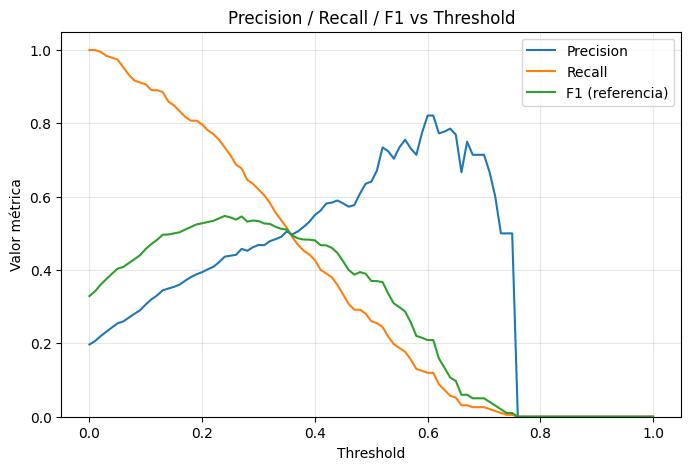

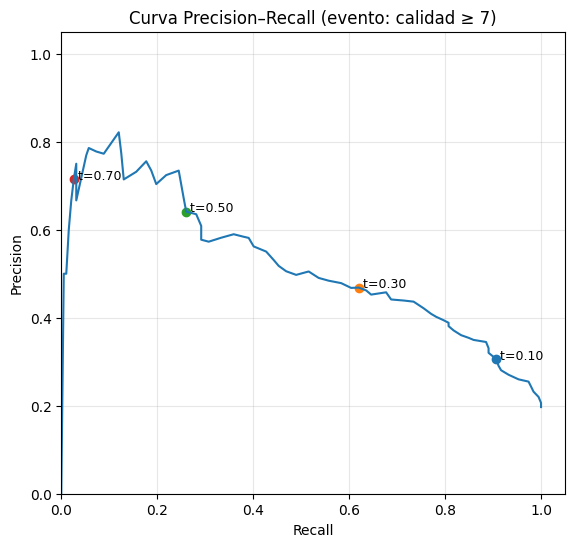

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Asegúrate de tener pr_df ya creado en 5.3 con columnas: threshold, precision, recall, f1

# --- 1) Precision y Recall vs threshold ---
plt.figure(figsize=(8, 5))
plt.plot(pr_df["threshold"], pr_df["precision"], label="Precision")
plt.plot(pr_df["threshold"], pr_df["recall"], label="Recall")
plt.plot(pr_df["threshold"], pr_df["f1"], label="F1 (referencia)")
plt.title("Precision / Recall / F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Valor métrica")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 2) Curva Precision–Recall (trade-off directo) ---
plt.figure(figsize=(6.5, 6))
plt.plot(pr_df["recall"], pr_df["precision"])
plt.title("Curva Precision–Recall (evento: calidad ≥ 7)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

# (Opcional) marcar algunos thresholds para interpretar visualmente
for t_mark in [0.1, 0.3, 0.5, 0.7]:
    row = pr_df.iloc[(pr_df["threshold"] - t_mark).abs().argmin()]
    plt.scatter(row["recall"], row["precision"])
    plt.text(row["recall"], row["precision"], f" t={row['threshold']:.2f}", fontsize=9)

plt.show()

> Estas gráficas muestran de forma visual el **trade-off inevitable** entre *precision*, *recall* y *threshold* cuando convertimos una probabilidad en una decisión.
>
> **Gráfica superior (métricas vs threshold):**
> Al aumentar el threshold, el modelo se vuelve más exigente:
>
> * la **precision** sube: acepta menos vinos, pero con mayor calidad,
> * el **recall** baja: empieza a dejar fuera vinos realmente buenos,
> * el **F1** alcanza un máximo intermedio y luego cae, mostrando que no existe un óptimo estable.
>
> Esto deja claro que no hay un threshold “correcto” desde lo técnico: cada punto representa un **compromiso distinto entre tipos de error**.
>
> **Gráfica inferior (curva Precision–Recall):**
> Cada punto de la curva corresponde a un threshold distinto.
> Moverse hacia la derecha aumenta el recall (se capturan más vinos buenos), pero reduce la precision (se aceptan más vinos no buenos).
> Moverse hacia arriba hace lo contrario: menos aceptaciones, pero más confiables.
>
> Los puntos marcados (t = 0.10, 0.30, 0.50, 0.70) ilustran políticas distintas, no mejoras técnicas.
>
> 📌 Estas curvas no dicen *qué threshold usar*.
> 📌 Muestran **qué se sacrifica y qué se gana** en cada elección.
> **La decisión final es de negocio, no del modelo.**


---
---
---

## 5.5 Matriz de confusión condicionada a un threshold

En este bloque vamos a **convertir la señal continua** `y_score_event` en una decisión binaria usando **un threshold ilustrativo**, y luego ver **qué tipo de errores produce esa política**.

La matriz de confusión nos deja ver, de forma tangible:
- cuántos vinos “buenos” detectamos (aciertos),
- cuántos “buenos” se nos escapan (errores por omisión),
- y cuántos “no buenos” estamos aceptando (errores por exceso).

📌 No buscamos el “mejor threshold”.  
📌 Buscamos ver cómo cambia el perfil de error cuando cambia la política.

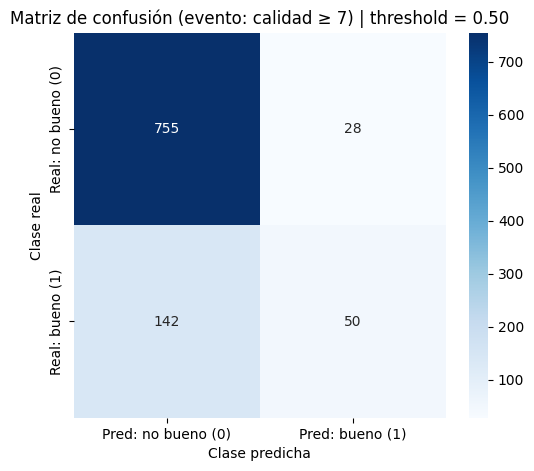

(np.int64(755), np.int64(28), np.int64(142), np.int64(50))

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Threshold ilustrativo (ajústalo si quieres comparar políticas)
t = 0.50

# Decisión binaria inducida por el threshold
y_pred_bin = (y_score_event >= t).astype(int)

# Matriz de confusión binaria: filas = real, columnas = predicho
cm_bin = confusion_matrix(y_true_bin, y_pred_bin)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_bin,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: no bueno (0)", "Pred: bueno (1)"],
    yticklabels=["Real: no bueno (0)", "Real: bueno (1)"]
)

plt.title(f"Matriz de confusión (evento: calidad ≥ 7) | threshold = {t:.2f}")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.show()

# Lectura rápida de conteos
tn, fp, fn, tp = cm_bin.ravel()
tn, fp, fn, tp

> Esta matriz muestra **qué errores produce la política** cuando fijamos un **threshold = 0.50** para el evento *vino bueno (calidad ≥ 7)*.
>
> * **755 TN**: vinos **no buenos** correctamente rechazados.
> * **28 FP**: vinos **no buenos** que el modelo acepta como buenos (*riesgo de colarse*).
> * **50 TP**: vinos **realmente buenos** correctamente aceptados.
> * **142 FN**: vinos **buenos** que el modelo rechaza (*riesgo de perder buenos*).
>
> Con este threshold, la política es **prudente**:
>
> * acepta pocos vinos (pocos FP),
> * pero **deja fuera una cantidad relevante de vinos buenos** (FN altos).
>
> La lectura clave no es si el número es “bueno” o “malo”, sino que **el threshold define explícitamente qué error estamos dispuestos a asumir**.
>
> 📌 Cambiar el threshold **no mejora el modelo**.
> 📌 Cambia la **política de decisión** y, con ella, el tipo de riesgo que aceptamos.

---
---
---

### **5.5.1 Impacto del threshold en el perfil de error**

En este bloque se comparan **distintas matrices de confusión generadas con diferentes thresholds** aplicados a la misma señal de probabilidad.

El objetivo es mostrar, de forma visual y directa, que:

* cambiar el threshold **no mejora el modelo**,
* cambia la **política de decisión**,
* y modifica explícitamente **qué tipo de errores estamos dispuestos a aceptar**.

📌 El modelo es el mismo.
📌 Lo que cambia es el costo que asumimos al decidir.

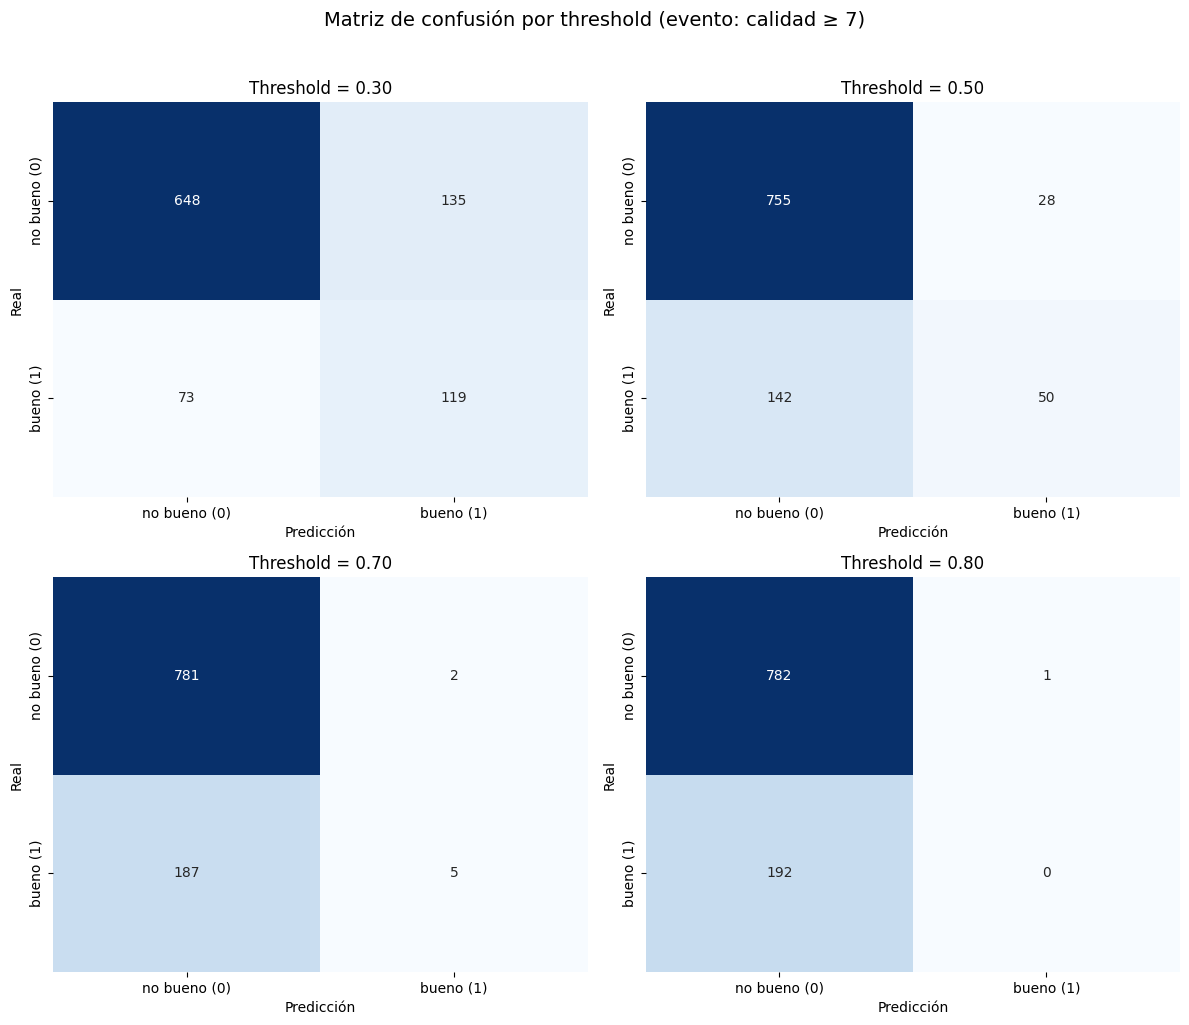

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Thresholds a comparar (ajústalos a tu gusto)
thresholds_to_compare = [0.30, 0.50, 0.70, 0.80]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

summary_rows = []

for ax, t in zip(axes, thresholds_to_compare):
    y_pred_bin = (y_score_event >= t).astype(int)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["no bueno (0)", "bueno (1)"],
        yticklabels=["no bueno (0)", "bueno (1)"]
    )

    ax.set_title(f"Threshold = {t:.2f}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

    # Métricas por threshold (para lectura rápida)
    prec = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec  = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1   = f1_score(y_true_bin, y_pred_bin, zero_division=0)

    summary_rows.append({
        "threshold": t,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tn": cm[0,0],
        "fp": cm[0,1],
        "fn": cm[1,0],
        "tp": cm[1,1],
    })

plt.suptitle("Matriz de confusión por threshold (evento: calidad ≥ 7)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Tabla resumen (recomendado para negocio)
import pandas as pd
summary_df = pd.DataFrame(summary_rows).sort_values("threshold")

> Estas matrices muestran **cómo cambia el perfil de errores cuando modificamos el threshold**, manteniendo fijo el mismo modelo y la misma señal de probabilidad.
>
> Con **threshold = 0.30**, la política es claramente **permisiva**: se detectan muchos vinos buenos (alto recall), pero también se aceptan muchos vinos no buenos (muchos falsos positivos). El sistema prioriza **no perder buenos vinos**, aunque a costa de colar ruido.
>
> Con **threshold = 0.50**, el comportamiento se vuelve más **equilibrado**: disminuyen notablemente los falsos positivos, pero empiezan a aparecer más vinos buenos rechazados. Aquí se ve explícitamente el intercambio entre **precision y recall**.
>
> Con **threshold = 0.70**, la política pasa a ser **restrictiva**: casi no se aceptan vinos no buenos, pero la mayoría de los vinos realmente buenos quedan fuera. El sistema protege la calidad de lo aceptado, sacrificando cobertura.
>
> Con **threshold = 0.80**, la política es **extrema**: prácticamente no se acepta ningún vino como bueno. El riesgo de falsos positivos es mínimo, pero el costo operativo es perder **todos** los vinos buenos.
>
> En conjunto, estas matrices dejan claro que:
>
> * el modelo no “mejora” ni “empeora”,
> * lo que cambia es **la política de decisión**,
> * y cada threshold define explícitamente **qué errores estamos dispuestos a asumir**.
>
> 📌 El threshold no optimiza al modelo.
> 📌 **Define el riesgo que el negocio decide aceptar.**

> Estos ejemplos muestran **qué decisiones concretas toma el sistema** cuando se fija un threshold y se aplica como política.
>
> Los **casos aceptados** son aquellos donde la probabilidad del evento supera el threshold: el sistema decide “este vino es bueno” y actúa en consecuencia.
> Los **casos rechazados** quedan fuera, aunque algunos de ellos sean realmente buenos.
>
> Los **falsos positivos** corresponden a vinos no buenos que la política acepta. No son errores del modelo: son el costo explícito de haber elegido un threshold permisivo.
>
> Los **falsos negativos** son vinos realmente buenos que la política rechaza. Aparecen cuando el threshold es más restrictivo y representan oportunidades perdidas.
>
> Visto fila a fila, queda claro que:
>
> * el modelo solo produce una **señal de probabilidad**,
> * el threshold convierte esa señal en una **decisión irreversible**,
> * y cada error observado es una **consecuencia directa de la política**, no del entrenamiento.
>
> 📌 Aquí no hay ajuste técnico.
> 📌 **Cada fila muestra el impacto real de la política elegida.**

---
---
---

## 5.2 Definir la probabilidad del evento (señal para el threshold)

En este punto convertimos la salida multiclase del modelo en **una única señal continua**, que será la “materia prima” del threshold.

Como el evento operativo es **vino bueno = calidad ≥ 7**, no nos interesa una clase aislada, sino la **probabilidad total del evento**:

- `p_evento = P(7) + P(8) + P(9)` (tomadas desde `y_proba`)

¿Para qué sirve esto?
- Tener una **escala 0–1** comparable entre observaciones.
- Poder aplicar **políticas explícitas** (thresholds) de aceptación / rechazo / revisión.
- Separar responsabilidades:
  - **modelo** = produce señal,
  - **negocio** = define la política (threshold).

📌 Sin `p_evento` no hay señal única.  
📌 Sin señal única no hay threshold defendible.

In [14]:
import numpy as np
import pandas as pd

# Etiquetas (orden de columnas en y_proba)
# Ajusta si tu modelo tiene otro orden; en tu caso ha sido: [3,4,5,6,7,8,9]
labels = np.array([3, 4, 5, 6, 7, 8, 9])

# Índices de clases del evento positivo: calidad >= 7
positive_idx = np.where(labels >= 7)[0]

# Señal continua del evento: P(calidad >= 7) = P(7)+P(8)+P(9)
y_score_event = y_proba[:, positive_idx].sum(axis=1)

# Dataset de inspección rápido
event_df = pd.DataFrame({
    "y_true_bin": y_true_bin,          # 1 si calidad>=7, 0 si no
    "p_evento": y_score_event          # señal continua para el threshold
})

event_df.head(10)

,y_true_bin,p_evento
0,0,0.021039
1,0,0.347173
2,0,0.017927
3,0,0.320736
4,1,0.316868
5,1,0.177426
6,0,0.236099
7,0,0.067012
8,0,0.212322
9,0,0.002529


> Esta tabla muestra, **fila a fila**, la relación entre la **realidad** y la **señal continua del modelo** para el evento *vino bueno (calidad ≥ 7)*.
>
> La columna **`y_true_bin`** indica el estado real:
>
> * `1` → el vino **sí es bueno** (calidad ≥ 7),
> * `0` → el vino **no es bueno**.
>
> La columna **`p_evento`** es la **probabilidad total** que el modelo asigna a que ese vino sea bueno.

**Lectura de algunos casos clave:**

> * **Fila 0** (`y_true_bin=0`, `p_evento=0.021`)
>   Vino no bueno con probabilidad muy baja.
>   El modelo está **alineado con la realidad** y con alta confianza.
>
> * **Fila 1** (`y_true_bin=0`, `p_evento=0.347`)
>   Vino no bueno, pero el modelo ve señales mixtas.
>   Caso **ambiguo**: con thresholds bajos podría aceptarse por error.
>
> * **Fila 4** (`y_true_bin=1`, `p_evento=0.317`)
>   Vino realmente bueno, pero con **confianza moderada**.
>   Con un threshold alto, este vino se perdería (**falso negativo**).
>
> * **Fila 5** (`y_true_bin=1`, `p_evento=0.177`)
>   Vino bueno con **baja probabilidad asignada**.
>   El modelo detecta mal este caso: es un buen ejemplo de riesgo operativo.
>
> * **Fila 9** (`y_true_bin=0`, `p_evento=0.0025`)
>   Vino no bueno con probabilidad casi nula.
>   Caso **claro y seguro** para rechazo.

**Conclusión operativa:**

> Estos ejemplos muestran que:
>
> * la señal `p_evento` **no separa perfectamente** buenos y no buenos,
> * existen zonas claras (probabilidad muy baja),
> * y zonas grises donde la decisión dependerá **exclusivamente del threshold**.
>
> 📌 El modelo entrega una **señal probabilística**,
> 📌 la política decidirá **qué hacer con la ambigüedad**.


In [15]:
# Lectura numérica rápida de la señal
event_df["p_evento"].describe()

count    975.000000
mean       0.195377
std        0.176047
min        0.000542
25%        0.051392
50%        0.132564
75%        0.311494
max        0.822019
Name: p_evento, dtype: float64

> Este resumen describe la **distribución global de la señal `p_evento`**, es decir, cómo el modelo reparte la probabilidad de *vino bueno (calidad ≥ 7)* en todo el conjunto de datos.
>
> **Qué nos dice cada estadístico:**
>
> * **count = 975**
>   Se analizaron 975 vinos. No hay valores faltantes.
>
> * **mean = 0.195**
>   En promedio, el modelo asigna una probabilidad baja a que un vino sea bueno.
>   Esto sugiere que, para el modelo, los vinos realmente “buenos” son **minoría**.
>
> * **std = 0.176**
>   Hay variabilidad considerable en la señal: el modelo distingue entre casos claros y casos ambiguos, no asigna siempre la misma probabilidad.
>
> * **min = 0.0005**
>   Existen vinos para los que el modelo está **prácticamente seguro** de que no son buenos.
>
> * **25% = 0.051**
>   El 25% de los vinos tiene una probabilidad muy baja de ser bueno.
>   Zona de **rechazo casi seguro** para cualquier política razonable.
>
> * **50% (mediana) = 0.133**
>   La mitad de los vinos tiene `p_evento` por debajo de ~0.13.
>   Esto confirma que la señal está **sesgada hacia valores bajos**.
>
> * **75% = 0.311**
>   Solo el 25% de los vinos supera este nivel de probabilidad.
>   A partir de aquí empieza la zona “interesante” para aceptar vinos.
>
> * **max = 0.822**
>   Incluso en el mejor caso, el modelo **no llega a certeza total**.
>   Esto indica que el problema es inherentemente ambiguo, no determinista.
>
> **Lectura clave:**
>
> 📌 La señal `p_evento` **no está pensada para decidir sola**.
> 📌 Su valor está en permitir **políticas graduadas**: rechazar lo obvio,
> revisar lo ambiguo y aceptar solo cuando el riesgo sea asumible.
>
> Aquí queda claro por qué el **threshold no es técnico**:
> elegirlo es decidir **qué parte de esta distribución estamos dispuestos a aceptar**.


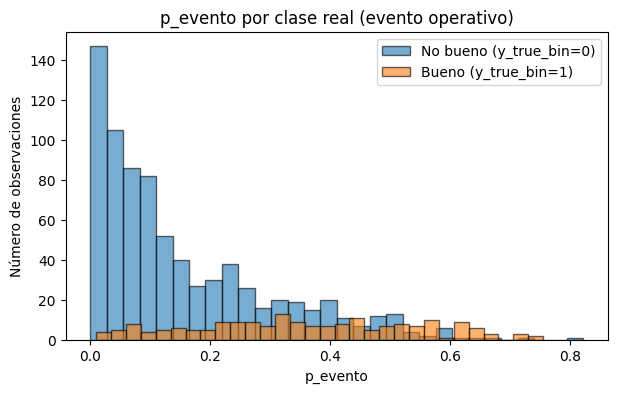

In [16]:
# 2) Distribución separada: vinos realmente buenos vs no buenos
p_pos = event_df.loc[event_df["y_true_bin"] == 1, "p_evento"]
p_neg = event_df.loc[event_df["y_true_bin"] == 0, "p_evento"]

plt.figure(figsize=(7, 4))
plt.hist(p_neg, bins=30, alpha=0.6, edgecolor="black", label="No bueno (y_true_bin=0)")
plt.hist(p_pos, bins=30, alpha=0.6, edgecolor="black", label="Bueno (y_true_bin=1)")
plt.title("p_evento por clase real (evento operativo)")
plt.xlabel("p_evento")
plt.ylabel("Número de observaciones")
plt.legend()
plt.show()

> Esta gráfica muestra **cómo se distribuye la probabilidad del evento (`p_evento`) según la clase real**, separando vinos **no buenos** (azul) de vinos **buenos** (naranja).
>
> Se observa que:
>
> * Los **vinos no buenos** se concentran fuertemente en valores bajos de `p_evento` (cerca de 0).
>   Para la mayoría de estos casos, el modelo tiene **alta confianza en rechazarlos**.
>
> * Los **vinos buenos** tienden a aparecer en valores más altos de `p_evento`, aunque **no forman un bloque separado**.
>   Esto indica que incluso los vinos realmente buenos **no siempre generan probabilidades altas**.
>
> * Existe una **zona de solapamiento** (aprox. entre 0.2 y 0.5) donde conviven vinos buenos y no buenos.
>   Esta es la región de **ambigüedad natural del problema**.
>
> La lectura clave es clara:
>
> 📌 No existe un threshold que separe perfectamente buenos y no buenos.
> 📌 Cualquier threshold va a generar **falsos positivos o falsos negativos**.
>
> Esta gráfica explica visualmente por qué:
>
> * el modelo produce una **señal razonable**,
> * pero la **decisión final** depende de **qué errores estamos dispuestos a aceptar**.
>
> Aquí no falta modelo.
> **Falta política.**